In [1]:
from lzn.universal import to_path


In [2]:
ads_l = ["co", "h2s", "h2o", "nh3"]
site_index = [f"{i:02d}" for i in range(0, 22, 2) if i != 16]
pj_path = to_path("~/organized")


### extract products infos

In [3]:
from parseName_extractEnergy import parseName_extractEnergy

In [4]:
info_dict = {}
info_dict["opt name"] = ["omol25", "r2scan", "svp"]
info_dict["opt index"] = [0, 1, 2]

get_opt_path = lambda index_, key_: pj_path / f"77{str(index_)}_{key_}_opt"
get_sp_path = lambda index_, key_: pj_path / f"79{str(index_)}_{key_}_opt_sp"
info_dict["opt path"] = list(map(get_opt_path, info_dict["opt index"], info_dict["opt name"]))
info_dict["sp path"] = list(map(get_sp_path, info_dict["opt index"], info_dict["opt name"]))


In [5]:
print(info_dict["opt path"])
info_dict["opt energy"] = list(map(parseName_extractEnergy, info_dict["opt path"]))
info_dict["sp energy"] = list(map(parseName_extractEnergy, info_dict["sp path"]))

[PosixPath('/home/zining/organized/770_omol25_opt'), PosixPath('/home/zining/organized/771_r2scan_opt'), PosixPath('/home/zining/organized/772_svp_opt')]
omol25
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
r2scan
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
svp
10 matching files
13 matching files
11 matching files
10 matching files
10+10+10+10 energies extracted
omol25
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
r2scan
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
svp
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted


In [6]:
print(info_dict["sp energy"])

[array([[-329569.12319005, -329569.07438371, -329568.81641433,
        -329568.89602668, -329568.73348491, -329568.71018652,
        -329568.737036  , -329568.7701577 , -329568.65123305,
        -329568.65160585],
       [-337352.6859726 , -337352.60230031, -337352.42332014,
        -337352.35095146, -337352.24936864, -337352.17437134,
        -337352.23081319, -337352.21612721, -337352.08208664,
        -337352.06978437],
       [-328566.89951572, -328566.81626249, -328566.6176874 ,
        -328566.48867005, -328566.39084784, -328566.30266935,
        -328566.66501344, -328566.33230799, -328566.21679565,
        -328566.2024743 ],
       [-328026.74083352, -328026.65232304, -328026.38103913,
        -328026.24338489, -328026.09461208, -328026.07790429,
        -328026.48154711, -328026.1483845 , -328025.94140381,
        -328025.92408105]]), array([[-329568.91632638, -329568.87423036, -329568.68805006,
        -329568.57833919, -329568.52434908, -329568.50352965,
        -329568.54003

### extract reactant infos

In [7]:
from lzn.parse_tore_mspa_out import exclude_unwanted_sites, parse_vs_tolist
from lzn.universal import parse_lzn_stem, hartree_to_eV

from ase.io import read

import numpy as np

In [8]:
# surface potential
cat_vmax_uni, _x = exclude_unwanted_sites(pj_path / "05_mspa_clusters" / "tio12CDa_opt-pbe0_def2tzvpS_hs.out")
cat_v = [i[2] for i in cat_vmax_uni]
print(cat_v)

ads_v_names = [f"{i}S_hs.out" for i in ads_l]
get_ads_vmin = lambda ads_v_name: parse_vs_tolist(pj_path / "05_mspa_adsorbates" / ads_v_name, vs="min")[0][2]
ads_vmin = list(map(get_ads_vmin, ads_v_names))
print(ads_vmin)



[124.67, 106.27, 62.43, 61.78, 51.16, 42.57, 40.89, 34.72, 23.0, 21.15]
[-13.28, -18.35, -36.72, -40.12]


In [9]:
# reactants energy
info_dict["opt i energy"] = np.array([-205.957535, -401.687866, -11994.7539400 * hartree_to_eV])
info_dict["sp i energy"] = np.array([-11998.1881525, -11998.1802856, -11998.1874453]) * hartree_to_eV

# tzvp sp energies
sp_ll = []
for opti in ["omol25_low_s", "matpes_r2scan", "pbe0_def2svp"]:
    sp_l = []
    for adsi in ads_l:
        pathi = pj_path / "041_adsorbates_sp" / f"{adsi}_opt-{opti}_sp-pbe0_def2tzvp.log"
        atoms = read(pathi, index= -1, format="gaussian-out")
        atoms_energy = atoms.get_potential_energy()
        sp_l.append(atoms_energy)
    sp_ll.append(sp_l)
info_dict["sp adsi energy"] = sp_ll

# opt energies
opt_ll = []
for opti in ["omol25_low_s", "matpes_r2scan"]:
    opt_l = []
    for adsi in ads_l:
        pathi = pj_path / "04_adsorbates_mlip_opt" / f"{adsi}_opt-{opti}.traj"
        atoms = read(pathi, index= -1, format="traj")
        atoms_energy = atoms.get_potential_energy()
        opt_l.append(atoms_energy)
    opt_ll.append(opt_l)
opt_l = []
for adsi in ads_l:
    pathi = pj_path / "04_adsorbates_g16_opt" / f"{adsi}_opt-pbe0_def2svp.log"
    atoms = read(pathi, index= -1, format="gaussian-out")
    atoms_energy = atoms.get_potential_energy()
    opt_l.append(atoms_energy)
opt_ll.append(opt_l)

info_dict["opt adsi energy"] = opt_ll

In [10]:
print(info_dict["sp adsi energy"])
print(info_dict["opt adsi energy"])

[[-3081.180393248423, -10864.467167090845, -2078.3399663639684, -1537.8149366185476], [-3081.1722294516567, -10864.467185812278, -2078.3392056587877, -1537.8130660480072], [-3081.1791132792478, -10864.465827773636, -2078.337589558245, -1537.8088512464933]]
[[-8.293752670288086, -7.737583160400391, -9.341156959533691, -12.802688598632812], [-16.61359405517578, -15.27695083618164, -15.391984939575195, -20.557151794433594], [-3077.509914286752, -10860.63335899558, -2075.5921243331713, -1535.8467420634154]]


In [11]:
# tzvp opt energies
opt_l = []
for adsi in ads_l:
    pathi = pj_path / "04_adsorbates_g16_opt" / f"{adsi}_opt-pbe0_def2tzvp.log"
    atoms = read(pathi, index= -1, format="gaussian-out")
    atoms_energy = atoms.get_potential_energy()
    opt_l.append(atoms_energy)

opt_l.append(-11998.1901986 * hartree_to_eV)
info_dict["ads+cat tzvpi energy"] = opt_l

### Results

In [12]:
info_dict.keys()

dict_keys(['opt name', 'opt index', 'opt path', 'sp path', 'opt energy', 'sp energy', 'opt i energy', 'sp i energy', 'sp adsi energy', 'opt adsi energy', 'ads+cat tzvpi energy'])

In [13]:
info_dict['opt energy']

[array([[-214.66938782, -214.64620972, -214.48205566, -214.44563293,
         -214.38899231, -214.36457825, -214.39112854, -214.47634888,
         -214.373703  , -214.37672424],
        [-214.36065674, -214.32313538, -214.16365051, -214.15933228,
         -214.0718689 , -213.99534607, -214.00149536, -214.03981018,
         -213.97380066, -213.95109558],
        [-216.33630371, -216.31402588, -216.12651062, -216.05685425,
         -215.97219849, -215.9087677 , -216.2052002 , -215.96122742,
         -215.84283447, -215.82910156],
        [-220.13729858, -220.09713745, -219.85186768, -219.76086426,
         -219.62194824, -219.61404419, -219.96113586, -219.68338013,
         -219.49157715, -219.48283386]]),
 array([[-418.79345703, -418.74719238, -418.54721069, -418.45880127,
         -418.3996582 , -418.37918091, -418.44546509, -418.46463013,
         -418.34170532, -418.34585571],
        [-417.52786255, -417.46710205, -417.27862549, -417.22998047,
         -417.17001343, -417.10244751, 

In [14]:
import pandas as pd
from matplotlib import pyplot as plt
from copy import deepcopy


In [15]:
# Find the method with the lowest tzvp sp energy of product
# stack into shape (3, m, n)
stacked = np.stack(info_dict['sp energy'], axis=0)

# find index of minimum along axis=0 → shape (m, n)
argmin = np.argmin(stacked, axis=0)
lowest_energies = np.min(stacked, axis=0)

# map indices to labels
labels = np.array(info_dict["opt name"])
result = labels[argmin]

# convert to DataFrame
df_tzvpcompare_opt = pd.DataFrame(result.T, index=site_index, columns=ads_l)

# summary counts
summary_tzvpcompare = pd.Series(result.ravel()).value_counts()


In [16]:
print(info_dict["sp i energy"])
print(info_dict["sp adsi energy"])

[-326487.48509475 -326487.2710254  -326487.46585085]
[[-3081.180393248423, -10864.467167090845, -2078.3399663639684, -1537.8149366185476], [-3081.1722294516567, -10864.467185812278, -2078.3392056587877, -1537.8130660480072], [-3081.1791132792478, -10864.465827773636, -2078.337589558245, -1537.8088512464933]]


In [17]:
# Find the method with the lowest tzvp sp energy of reactant
# stack into shape (3, n)
ll = []
for i, l in enumerate(info_dict["sp adsi energy"]):
    v = info_dict["sp i energy"][i]
    l.append(v)
    ll.append(l)
stacked = np.stack(ll, axis=0)
print(stacked)

# find index of minimum along axis=0 → shape (m, n)
argmin = np.argmin(stacked, axis=0)
vmin = np.min(stacked, axis=0)

# map indices to labels
labels = np.array(info_dict["opt name"])
col0 = labels[argmin]
col1 = vmin

# compare to tzvp opt
col2 = np.array(info_dict["ads+cat tzvpi energy"])
col3 = (col1 - col2) * 1E6

# convert to DataFrame
col_tot = np.stack((col0, col1, col2, col3)).T
index = ads_l.append("cluster")
df_itzvpcompare_opt = pd.DataFrame(col_tot, index=ads_l, columns=["method", "E", "E tzvp", "dE/mueV"])


[[  -3081.18039325  -10864.46716709   -2078.33996636   -1537.81493662
  -326487.48509475]
 [  -3081.17222945  -10864.46718581   -2078.33920566   -1537.81306605
  -326487.2710254 ]
 [  -3081.17911328  -10864.46582777   -2078.33758956   -1537.80885125
  -326487.46585085]]


In [18]:
cat_v.insert(0, None)
get_array_tot = lambda dE: np.insert(np.insert(dE, 0, ads_vmin, axis=0), 0, cat_v, axis=1)


In [19]:
site_index.insert(0, "Vsmin")
ads_l.insert(0, "Vsmax")
ads_l.pop()

get_df_dE = lambda array_tot: pd.DataFrame(array_tot, index=site_index, columns=ads_l)

### Use the lowest energies

In [20]:
from lzn.universal import eV_to_kJdmol
print(ads_vmin)

[-13.28, -18.35, -36.72, -40.12]


In [21]:
# lowest_energies: the lowest tzvp energies for products
# col2: the lowest energies of reactants, from tzvp
E_isum = np.delete(col2 + col2[-1], -1)
E_f = lowest_energies.T
dE = (E_f - E_isum) * eV_to_kJdmol

array_tot = get_array_tot(dE)
array_tot

array([[          nan,  -13.28      ,  -18.35      ,  -36.72      ,
         -40.12      ],
       [ 124.67      ,  -38.78085756,  -65.39851509,  -98.27782955,
        -133.6439066 ],
       [ 106.27      ,  -34.07176265,  -57.32536838,  -90.24511552,
        -125.10394618],
       [  62.43      ,   -9.18150752,  -40.05641159,  -71.08553695,
         -98.92903441],
       [  61.78      ,  -16.8629298 ,  -33.07389714,  -58.63725879,
         -85.64742289],
       [  51.16      ,   -1.45387647,  -23.27264701,  -49.19885262,
         -71.29303249],
       [  42.57      ,    1.06791527,  -16.03650937,  -40.69092328,
         -69.68097614],
       [  40.89      ,   -1.58830201,  -21.48231929,  -75.65180472,
        -108.62657733],
       [  34.72      ,   -5.68933137,  -20.0653375 ,  -43.55061673,
         -76.48128096],
       [  23.        ,    6.59879136,   -7.28834687,  -32.4053737 ,
         -56.51068576],
       [  21.15      ,    6.72008941,   -6.31087361,  -31.0235736 ,
         -54

In [22]:
df_dE = get_df_dE(array_tot)
df_dE

,Vsmax,co,h2s,h2o,nh3
Vsmin,NaN,-13.280000,-18.350000,-36.720000,-40.120000
00,124.67,-38.780858,-65.398515,-98.277830,-133.643907
02,106.27,-34.071763,-57.325368,-90.245116,-125.103946
04,62.43,-9.181508,-40.056412,-71.085537,-98.929034
06,61.78,-16.862930,-33.073897,-58.637259,-85.647423
08,51.16,-1.453876,-23.272647,-49.198853,-71.293032
10,42.57,1.067915,-16.036509,-40.690923,-69.680976
12,40.89,-1.588302,-21.482319,-75.651805,-108.626577
14,34.72,-5.689331,-20.065338,-43.550617,-76.481281
18,23.00,6.598791,-7.288347,-32.405374,-56.510686


### Use omol25_low tzvp energies

In [23]:
print(info_dict.keys())
E0_omol = np.array(info_dict['sp adsi energy'][0])
E0_omol = E0_omol + E0_omol[-1]
E0_omol = np.delete(E0_omol, -1, axis=0)
E0_omol

dict_keys(['opt name', 'opt index', 'opt path', 'sp path', 'opt energy', 'sp energy', 'opt i energy', 'sp i energy', 'sp adsi energy', 'opt adsi energy', 'ads+cat tzvpi energy'])


array([-329568.665488  , -337351.95226184, -328565.82506111,
       -328025.30003137])

In [24]:
E1_omol = info_dict['sp energy'][0].T
dE_omol = (E1_omol - E0_omol) * eV_to_kJdmol
dE_omol_tot = get_array_tot(dE_omol)
df_dE_omol = get_df_dE(dE_omol_tot)
df_dE_omol

,Vsmax,co,h2s,h2o,nh3
Vsmin,NaN,-13.280000,-18.350000,-36.720000,-40.120000
00,124.67,-44.161524,-70.792309,-103.669083,-139.016238
02,106.27,-39.452429,-62.719162,-95.636369,-130.476278
04,62.43,-14.562173,-45.450205,-76.476791,-104.301366
06,61.78,-22.243596,-38.467691,-64.028513,-91.019755
08,51.16,-6.560703,-28.666440,-54.590106,-76.665364
10,42.57,-4.312751,-21.430303,-46.082177,-75.053308
12,40.89,-6.903331,-26.876113,-81.043059,-113.998909
14,34.72,-10.099088,-25.459131,-48.941871,-81.853613
18,23.00,1.375393,-12.526186,-37.796628,-61.883018


### Conclusions

In [25]:
print("The methods with lowest tzvp sp energy for products")
print(summary_tzvpcompare)
general_save = to_path("~/organized/901_data")

df_tzvpcompare_opt.to_csv(general_save / "methodwithlowestsp_ads.csv")

The methods with lowest tzvp sp energy for products
omol25    34
svp        6
Name: count, dtype: int64


In [26]:
print("The methods with lowest tzvp sp energy for products.\n"
      "compare to tzvp opt energies")
df_itzvpcompare_opt

The methods with lowest tzvp sp energy for products.
compare to tzvp opt energies


,method,E,E tzvp,dE/mueV
co,omol25,-3081.180393248423,-3081.180482692249,89.44382580011734
h2s,r2scan,-10864.467185812278,-10864.4673925916,206.77932116086595
h2o,omol25,-2078.3399663639684,-2078.3401655431508,199.17918234568788
nh3,omol25,-1537.8149366185476,-1537.8149396852707,3.0667231385450577
cluster,omol25,-326487.48509475036,-326487.5407719938,55677.24345019087


In [27]:
print("Use the lowest energies to calc dE/kJ*mol-1.\n"
      "Reactants opt by tzvp. This might lead to unexpected higher dE")
df_dE

Use the lowest energies to calc dE/kJ*mol-1.
Reactants opt by tzvp. This might lead to unexpected higher dE


,Vsmax,co,h2s,h2o,nh3
Vsmin,NaN,-13.280000,-18.350000,-36.720000,-40.120000
00,124.67,-38.780858,-65.398515,-98.277830,-133.643907
02,106.27,-34.071763,-57.325368,-90.245116,-125.103946
04,62.43,-9.181508,-40.056412,-71.085537,-98.929034
06,61.78,-16.862930,-33.073897,-58.637259,-85.647423
08,51.16,-1.453876,-23.272647,-49.198853,-71.293032
10,42.57,1.067915,-16.036509,-40.690923,-69.680976
12,40.89,-1.588302,-21.482319,-75.651805,-108.626577
14,34.72,-5.689331,-20.065338,-43.550617,-76.481281
18,23.00,6.598791,-7.288347,-32.405374,-56.510686


In [28]:
df_dE_omol

,Vsmax,co,h2s,h2o,nh3
Vsmin,NaN,-13.280000,-18.350000,-36.720000,-40.120000
00,124.67,-44.161524,-70.792309,-103.669083,-139.016238
02,106.27,-39.452429,-62.719162,-95.636369,-130.476278
04,62.43,-14.562173,-45.450205,-76.476791,-104.301366
06,61.78,-22.243596,-38.467691,-64.028513,-91.019755
08,51.16,-6.560703,-28.666440,-54.590106,-76.665364
10,42.57,-4.312751,-21.430303,-46.082177,-75.053308
12,40.89,-6.903331,-26.876113,-81.043059,-113.998909
14,34.72,-10.099088,-25.459131,-48.941871,-81.853613
18,23.00,1.375393,-12.526186,-37.796628,-61.883018


### Plot

In [29]:
def plotttt(df, title_list, fig1):
    global plot_index
    grid_name = fig1.add_subplot(gs[plot_index, 0])
    grid_name.set_title(title_list[plot_index])

    df_tmp = df.iloc[1:,:]
    x_vsmax = df_tmp.iloc[:, 0]
    for i in range(1, len(df_tmp.columns)):
        y_energy = df_tmp.iloc[:, i]
        grid_name.plot(x_vsmax, y_energy, "o-", label=df_tmp.columns[i])
        print(df_tmp.columns[i])

    grid_name.legend()
    grid_name.set_xlabel("Vsmax")
    grid_name.set_ylabel("dE kJ/mol")
    grid_name.grid(True)

    print(plot_index)
    plot_index += 1

    return fig1

co
h2s
h2o
nh3
0
co
h2s
h2o
nh3
1


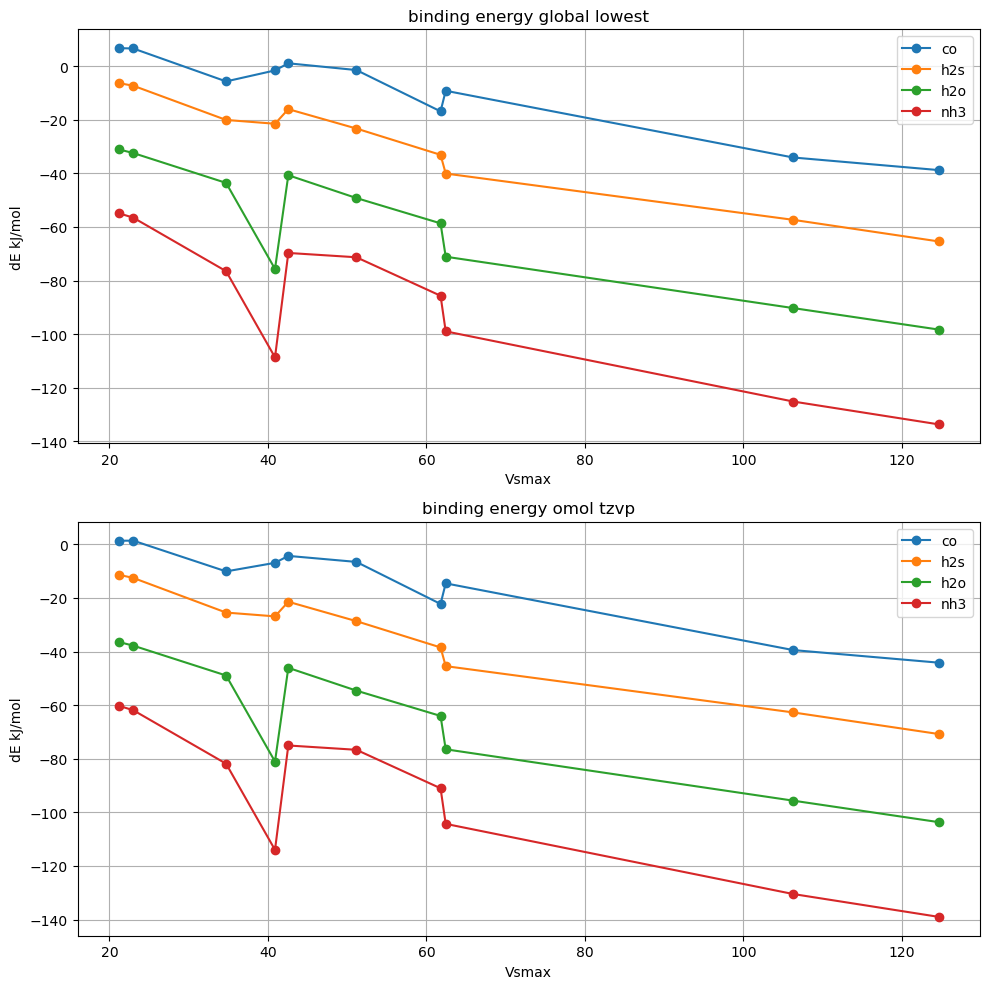

In [30]:
# plot
plot_index = 0

fig1 = plt.figure(1, figsize = (10,10))
gs = fig1.add_gridspec(2,1)

title_list = ["binding energy global lowest", "binding energy omol tzvp"]
fig1 = plotttt(df_dE, title_list, fig1)
fig1 = plotttt(df_dE_omol, title_list, fig1)

fig1.tight_layout()
plt.show()


### All dE

In [31]:
print(info_dict.keys())
col1 = np.array([info_dict['opt i energy']]).T
col3 = np.array(info_dict['opt adsi energy'])
col2 = np.array(info_dict['sp adsi energy'])

info_dict['opt sum i energy'] = col3 + col1
info_dict['sp sum i energy'] = np.delete(col2 + np.array([col2[:,-1]]).T, -1, axis=1)

print(info_dict['opt sum i energy'])
print(info_dict['sp sum i energy'])

dict_keys(['opt name', 'opt index', 'opt path', 'sp path', 'opt energy', 'sp energy', 'opt i energy', 'sp i energy', 'sp adsi energy', 'opt adsi energy', 'ads+cat tzvpi energy'])
[[-2.14251288e+02 -2.13695118e+02 -2.15298692e+02 -2.18760224e+02]
 [-4.18301460e+02 -4.16964817e+02 -4.17079851e+02 -4.22245018e+02]
 [-3.29471545e+05 -3.37254669e+05 -3.28469627e+05 -3.27929882e+05]]
[[-329568.665488   -337351.95226184 -328565.82506111 -328025.30003137]
 [-329568.44325485 -337351.73821121 -328565.61023105 -328025.08409144]
 [-329568.64496413 -337351.93167862 -328565.80344041 -328025.2747021 ]]


In [32]:
# opt * abs * sites
print(info_dict['opt energy'])
print(info_dict['sp energy'])

[array([[-214.66938782, -214.64620972, -214.48205566, -214.44563293,
        -214.38899231, -214.36457825, -214.39112854, -214.47634888,
        -214.373703  , -214.37672424],
       [-214.36065674, -214.32313538, -214.16365051, -214.15933228,
        -214.0718689 , -213.99534607, -214.00149536, -214.03981018,
        -213.97380066, -213.95109558],
       [-216.33630371, -216.31402588, -216.12651062, -216.05685425,
        -215.97219849, -215.9087677 , -216.2052002 , -215.96122742,
        -215.84283447, -215.82910156],
       [-220.13729858, -220.09713745, -219.85186768, -219.76086426,
        -219.62194824, -219.61404419, -219.96113586, -219.68338013,
        -219.49157715, -219.48283386]]), array([[-418.79345703, -418.74719238, -418.54721069, -418.45880127,
        -418.3996582 , -418.37918091, -418.44546509, -418.46463013,
        -418.34170532, -418.34585571],
       [-417.52786255, -417.46710205, -417.27862549, -417.22998047,
        -417.17001343, -417.10244751, -417.14276123, -

In [33]:
dE_dict = {}

def get_all_dE(product_l, reactant_l, description):
    global dE_dict
    for i, opti in enumerate(info_dict['opt name']):
        opti_f = product_l[i]
        opti_i = np.array([reactant_l[i]]).T
        dEi = (opti_f - opti_i) * eV_to_kJdmol
        dE_dict[opti + ' ' + description] = dEi
    return 0



In [34]:
get_all_dE(info_dict['opt energy'], info_dict['opt sum i energy'], "opt")
get_all_dE(info_dict['sp energy'], info_dict['sp sum i energy'], "sp")
dE_dict.keys()

dict_keys(['omol25 opt', 'r2scan opt', 'svp opt', 'omol25 sp', 'r2scan sp', 'svp sp'])

In [35]:
print(dE_dict['omol25 opt'], end="\n\n")
print(dE_dict['omol25 sp'])

[[ -40.34052126  -38.1041751   -22.26572084  -18.75146259  -13.28647447
   -10.93087614  -13.49258932  -21.71509973  -11.81128101  -12.10278631]
 [ -64.21469434  -60.59443416  -45.20648808  -44.78984163  -36.35091062
   -28.96758211  -29.56089844  -33.25771557  -26.88876659  -24.69806014]
 [-100.1142889   -97.96480542  -79.87233802  -73.15152154  -64.98348434
   -58.86334544  -87.46472588  -63.92493734  -52.5017577   -51.17673364]
 [-132.86750341 -128.99254416 -105.32761446  -96.5471217   -83.14376721
   -82.38114225 -115.87038923  -89.0710415   -70.56487214  -69.72127349]]

[[ -44.16152353  -39.45242862  -14.56217349  -22.24359577   -6.5607029
    -4.3127507    -6.90333051  -10.09908783    1.37539277    1.33942344]
 [ -70.79230855  -62.71916184  -45.45020505  -38.4676906   -28.66644048
   -21.43030283  -26.87611275  -25.45913097  -12.5261857   -11.33919762]
 [-103.66908337  -95.63636934  -76.47679077  -64.0285126   -54.59010644
   -46.0821771   -81.04305853  -48.94187055  -37.79662752

In [36]:
df_dE_dict = {} # adsorption energies in kJ/mol
df_ddE_dict = {} # adsorption energies relative to svp opt, tzvp sp

ref_dE = dE_dict['svp sp'].T

ddE_maxdev = []
ddE_meandev = []
ddE_stdev = []

for i in dE_dict.keys():
    dEi = dE_dict[i].T
    ddEi = dEi - ref_dE

    keyi = "df " + i

    # dataframes about dE
    dfi = get_df_dE(get_array_tot(dEi))
    print(keyi)
    print(dfi)
    df_dE_dict[keyi] = dfi

    # dataframes about ddE
    df_ddEi = get_df_dE(get_array_tot(ddEi))
    df_ddE_dict[keyi] = df_ddEi

    # statistics on ddE
    ddE_maxdev.append(np.max(np.abs(ddEi)))
    ddE_meandev.append(np.average(ddEi))
    ddE_stdev.append(np.sqrt(np.average(ddEi ** 2)))

df omol25 opt
        Vsmax         co        h2s         h2o         nh3
Vsmin     NaN -13.280000 -18.350000  -36.720000  -40.120000
00     124.67 -40.340521 -64.214694 -100.114289 -132.867503
02     106.27 -38.104175 -60.594434  -97.964805 -128.992544
04      62.43 -22.265721 -45.206488  -79.872338 -105.327614
06      61.78 -18.751463 -44.789842  -73.151522  -96.547122
08      51.16 -13.286474 -36.350911  -64.983484  -83.143767
10      42.57 -10.930876 -28.967582  -58.863345  -82.381142
12      40.89 -13.492589 -29.560898  -87.464726 -115.870389
14      34.72 -21.715100 -33.257716  -63.924937  -89.071042
18      23.00 -11.811281 -26.888767  -52.501758  -70.564872
20      21.15 -12.102786 -24.698060  -51.176734  -69.721273
df r2scan opt
        Vsmax         co        h2s        h2o         nh3
Vsmin     NaN -13.280000 -18.350000 -36.720000  -40.120000
00     124.67 -47.470480 -54.325639 -91.884366 -127.085286
02     106.27 -43.006621 -48.463143 -87.770902 -119.691652
04      62.43 -2

In [37]:
for ii, i in enumerate(df_ddE_dict.keys()):
    print(i)
    print(f"maxdev: {ddE_maxdev[ii]}; meandev: {ddE_meandev[ii]}; stdev: {ddE_stdev[ii]}")
    print(df_ddE_dict[i])


df omol25 opt
maxdev: 15.079300951558672; meandev: -5.26401192232306; stdev: 8.070201703380972
        Vsmax         co        h2s        h2o        nh3
Vsmin     NaN -13.280000 -18.350000 -36.720000 -40.120000
00     124.67   5.177436   6.651442   3.794099   7.352090
02     106.27   2.747483   2.798219  -2.299696   1.741909
04      62.43  -7.149729   0.603724  -3.390962   0.155315
06      61.78   4.466294  -5.772321  -8.010463  -4.496245
08      51.16  -4.471680  -8.344207 -11.359965  -7.490970
10      42.57  -5.886298  -7.635685 -13.465252  -8.266099
12      40.89  -4.543369  -2.500425  -7.096824  -1.572610
14      34.72  -8.664850  -8.074736 -15.079301  -7.611428
18      23.00 -11.049154 -12.220648 -14.562444  -7.902256
20      21.15 -12.475138 -11.007415 -14.670942  -8.977372
df r2scan opt
maxdev: 16.540497122544338; meandev: 5.190787562578614; stdev: 8.491193865463229
        Vsmax         co        h2s        h2o        nh3
Vsmin     NaN -13.280000 -18.350000 -36.720000 -40.12000

In [38]:
# for ii, i in enumerate(df_ddE_dict.keys()):
#     df_ddE_dict[i].to_csv(general_save / i)

### plot all dE

reactants: omol, matpes, svp, tzvp opt; + tzvp sp
products: omol, matpes, svp opt; + tzvp sp

Goal: compare the new method to traditional one (svp opt + tzvp sp).
Assumption: svp opt + tzvp sp predict accurate results.
!!! even its absolute energies is very bad. But the relative energies are good. => it has good adsorption energy.

1. compare new opt binding energies wrt tranditional method energies. If a method have similar binding energy to tzvp does, it is good in predicting binding energy.


Results:
1. omol opt have the overall lowest sp energy. => omol opt structure is the most close one to tzvp minimum for both reactants and products. => omol is good, if we trust tzvp.